## Giai đoạn 1: Phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA)

- Tải và kiểm tra tổng quan dữ liệu
- Vẽ biểu đồ phân phối từng biến
- Vẽ correlation heatmap giữa features và Burn Out
- Phân tích theo nhóm nhân khẩu học (Gender, Age, Designation vs Burn Out)
- Ghi lại nhận xét EDA

In [ ]:
pip install -r ../requirements.txt

### Task 1: Tải và kiểm tra thông tin tổng quan của dữ liệu

In [23]:
import pandas as pd

file_path = "../data/csv/Raw_Data_DIB.csv"

def load_and_explore_data(filepath):
    try:
        print(f"🔃 Đang tải dữ liệu từ: {filepath}")
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()
        print("✅ Tải dữ liệu thành công!\n")

        print("-" * 30)
        print("--- THÔNG TIN TỔNG QUAN ---")
        print(f"🔵 Tổng số quan sát (Dòng): {df.shape[0]}")
        print(f"🔵 Tổng số biến (Cột): {df.shape[1]}\n")

        print("--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
        display(df.head())

        print("\n--- KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ---")
        missing_data = df.isnull().sum()
        if missing_data.sum() == 0:
            print("✅ Tuyệt vời, dataset không có dữ liệu nào bị trống (Null/NA)!\n")
        else:
            print("‼️ Các cột có dữ liệu bị thiếu:")
            print(missing_data[missing_data > 0], "\n")

        if 'Burn Out' in df.columns:
            X = df.drop(columns=['Burn Out'])
            y = df['Burn Out']

            print("-" * 30)
            print("--- PHÂN TÁCH BIẾN THÀNH CÔNG ---")
            print(f"🔵 Kích thước ma trận đặc trưng (X): {X.shape}")
            print(f"🔵 Kích thước vector mục tiêu (y): {y.shape}")

            print("\nPhân phối của cột 'Burn Out' (Target):")
            print(y.value_counts().sort_index())

            return df, X, y
        else:
            print("⚠️ Lỗi: Không tìm thấy cột 'Burn Out' trong tập dữ liệu.")
            return df, None, None

    except FileNotFoundError:
        print(f"❌ Không tìm thấy file tại đường dẫn: '{filepath}'.")
        return None, None, None
    except Exception as e:
        print(f"❌ Có lỗi bất ngờ xảy ra: {e}")
        return None, None, None

df_raw, X_features, y_target = load_and_explore_data(file_path)

🔃 Đang tải dữ liệu từ: ../data/csv/Raw_Data_DIB.csv
✅ Tải dữ liệu thành công!

------------------------------
--- THÔNG TIN TỔNG QUAN ---
🔵 Tổng số quan sát (Dòng): 1434
🔵 Tổng số biến (Cột): 25

--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,Gender,Age code,BMI,Designation,Specialization,Working_Place,Duration,Private_Practice,Working_Hour,Weekly_Vacation,...,Vacation_with_Family,Family_Functions,Disappointing_Thing,Feelings,Conflict,Dissatisfaction,Mental_Disturbances,Politics,Flexibility,Burn Out
0,2,3,3,9,16,1,5,1,1,1,...,1,1,7,6,4,7,9,1,1,4
1,1,2,2,8,16,1,4,1,1,1,...,1,2,1,1,1,5,3,2,1,3
2,1,2,2,8,16,1,4,1,1,1,...,1,2,7,1,1,5,3,2,1,4
3,1,2,2,8,16,1,3,3,2,1,...,3,2,1,3,3,1,4,1,1,3
4,2,3,1,4,11,1,5,1,1,1,...,1,1,8,2,4,6,4,1,1,4



--- KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ---
✅ Tuyệt vời, dataset không có dữ liệu nào bị trống (Null/NA)!

------------------------------
--- PHÂN TÁCH BIẾN THÀNH CÔNG ---
🔵 Kích thước ma trận đặc trưng (X): (1434, 24)
🔵 Kích thước vector mục tiêu (y): (1434,)

Phân phối của cột 'Burn Out' (Target):
Burn Out
1     36
2    316
3    714
4    300
5     68
Name: count, dtype: int64


### Task 2: Thiết lập thư viện và cấu hình đồ thị

- Import tất cả thư viện cần dùng và định nghĩa metadata cho từng biến (nhãn hiển thị, nhóm phân loại) để các ô tiếp theo có thể tái sử dụng.

In [24]:
# Cấu hình cảnh báo
warnings.filterwarnings('ignore')

#  Import thư viện 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#  Cấu hình style đồ thị
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

#  Nhãn hiển thị cho từng biến 
LABEL_MAP = {
    'Gender':               {1: 'Nam', 2: 'Nữ'},
    'Age code':             {1: '<25', 2: '25–34', 3: '35–44', 4: '45–54', 5: '≥55'},
    'BMI':                  {1: 'Gầy', 2: 'Bình thường', 3: 'Thừa cân', 4: 'Béo phì'},
    'Marital_Status':       {1: 'Độc thân', 2: 'Đã kết hôn', 3: 'Ly hôn', 4: 'Góa'},
    'Income':               {1: '<20k', 2: '20–40k', 3: '40–50k', 4: '50–100k', 5: '>100k'},
    'Liabilities':          {1: 'Có', 2: 'Không'},
    'Staying_with_Family':  {1: 'Có', 2: 'Không'},
    'Vacation_with_Family': {1: 'Thỉnh thoảng', 2: 'Hiếm khi', 3: 'Không bao giờ'},
    'Family_Functions':     {1: 'Thỉnh thoảng', 2: 'Hiếm khi', 3: 'Không thường xuyên'},
    'Politics':             {1: 'Có lo ngại', 2: 'Không lo ngại'},
    'Flexibility':          {1: 'Đồng ý', 2: 'Không đồng ý'},
    'Private_Practice':     {1: 'Trong TP', 2: 'Ngoài TP', 3: 'Không'},
    'Burn Out':             {1: 'Không có dấu hiệu', 2: 'Ít dấu hiệu',
                             3: 'Cần chú ý', 4: 'Nguy cơ cao', 5: 'Nguy cơ rất cao'},
}

#  Phân nhóm biến theo loại
# Biến nhị phân (Binary) là trường hợp đặc biệt của nominal, chỉ có đúng 2 giá trị có thể xảy ra.
BINARY_COLS   = ['Gender', 'Liabilities', 'Staying_with_Family', 'Politics', 'Flexibility']

# Biến thứ bậc (Ordinal) cũng là nhóm rời rạc nhưng có thứ tự rõ ràng -> nhóm cao hơn thực sự mang nghĩa "nhiều hơn".
ORDINAL_COLS  = ['Age code', 'BMI', 'Income', 'Family_members', 'Duration',
                 'Working_Hour', 'Weekly_Vacation']

# Biến danh nghĩa (Nominal) có nhiều hơn 2 nhóm nhưng các nhóm không có thứ tự -> không thể nói nhóm này "lớn hơn" hay "tốt hơn" nhóm kia.
NOMINAL_COLS  = ['Designation', 'Specialization', 'Working_Place', 'Private_Practice',
                 'Marital_Status', 'Vacation_with_Family', 'Family_Functions',
                 'Disappointing_Thing', 'Feelings', 'Conflict',
                 'Dissatisfaction', 'Mental_Disturbances']

TARGET_COL    = 'Burn Out'

# Màu cho 5 nhóm Burn Out 
BURNOUT_PALETTE = {
    1: '#4CAF50',   # xanh lá - không có dấu hiệu
    2: '#8BC34A',   # xanh nhạt - ít dấu hiệu
    3: '#FFC107',   # vàng      - cần chú ý
    4: '#FF5722',   # cam đậm   - nguy cơ cao
    5: '#C62828',   # đỏ đậm    - nguy cơ rất cao
}

print("✅ Thiết lập hoàn tất. Sẵn sàng phân tích!")

✅ Thiết lập hoàn tất. Sẵn sàng phân tích!


### Task 3: Phân phối biến mục tiêu (Burn Out)

- Kiểm tra mức độ mất cân bằng lớp trước khi đi vào phân tích chi tiết.

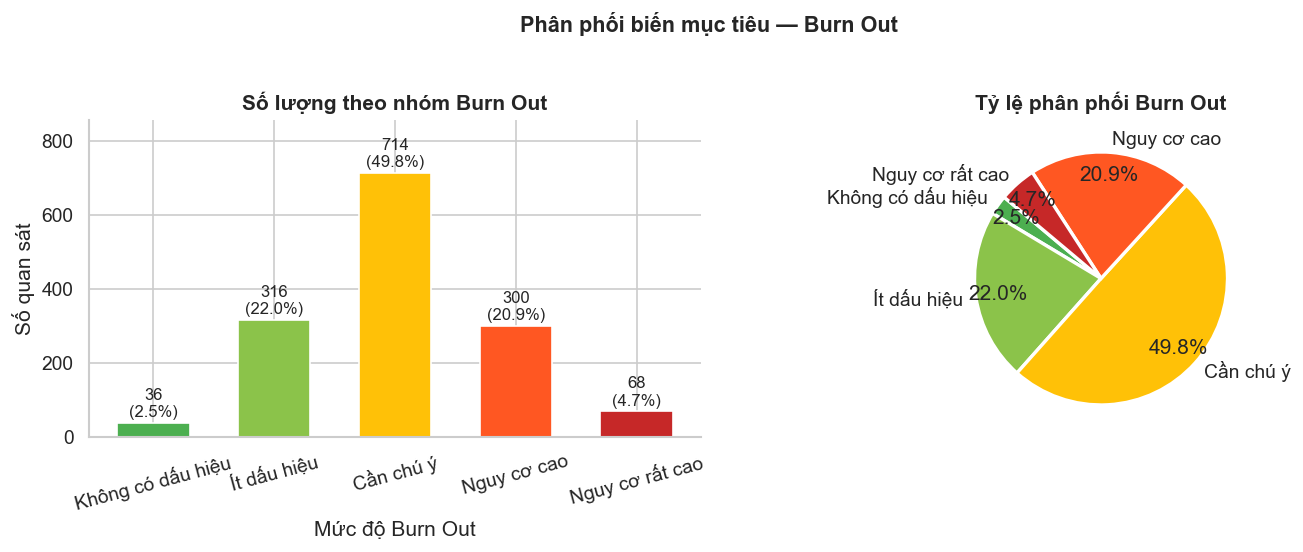


📊 Bảng tóm tắt:


,Nhóm,Số lượng,Tỷ lệ (%)
0,Không có dấu hiệu,36,2.5
1,Ít dấu hiệu,316,22.0
2,Cần chú ý,714,49.8
3,Nguy cơ cao,300,20.9
4,Nguy cơ rất cao,68,4.7



✅ Phân phối tương đối cân bằng.


In [25]:
counts    = df_raw[TARGET_COL].value_counts().sort_index()
pct       = (counts / counts.sum() * 100).round(1)
labels    = [LABEL_MAP[TARGET_COL].get(k, str(k)) for k in counts.index]
colors    = [BURNOUT_PALETTE[k] for k in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, width=0.6, edgecolor='white')
for bar, n, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{n}\n({p}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Số lượng theo nhóm Burn Out', fontweight='bold')
axes[0].set_xlabel('Mức độ Burn Out')
axes[0].set_ylabel('Số quan sát')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, wedgeprops=wedge_props,
            startangle=140, pctdistance=0.82)
axes[1].set_title('Tỷ lệ phân phối Burn Out', fontweight='bold')

plt.suptitle('Phân phối biến mục tiêu — Burn Out', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', bbox_inches='tight')
plt.show()

# Nhận xét class imbalance
print("\n📊 Bảng tóm tắt:")
summary = pd.DataFrame({'Nhóm': labels, 'Số lượng': counts.values, 'Tỷ lệ (%)': pct.values})
display(summary)

dominant = pct.max()
if dominant > 50:
    print(f"\n⚠️  CLASS IMBALANCE: Nhóm chiếm đa số chiếm {dominant}% -> Cần xử lý khi huấn luyện mô hình (class_weight='balanced' hoặc SMOTE).")
else:
    print("\n✅ Phân phối tương đối cân bằng.")

### Task 4: Phân phối các biến nhị phân (Binary)

- Khảo sát 5 biến có 2 giá trị: **Giới tính, Trách nhiệm pháp lý, Sống cùng gia đình, Chính trị, Linh hoạt.**

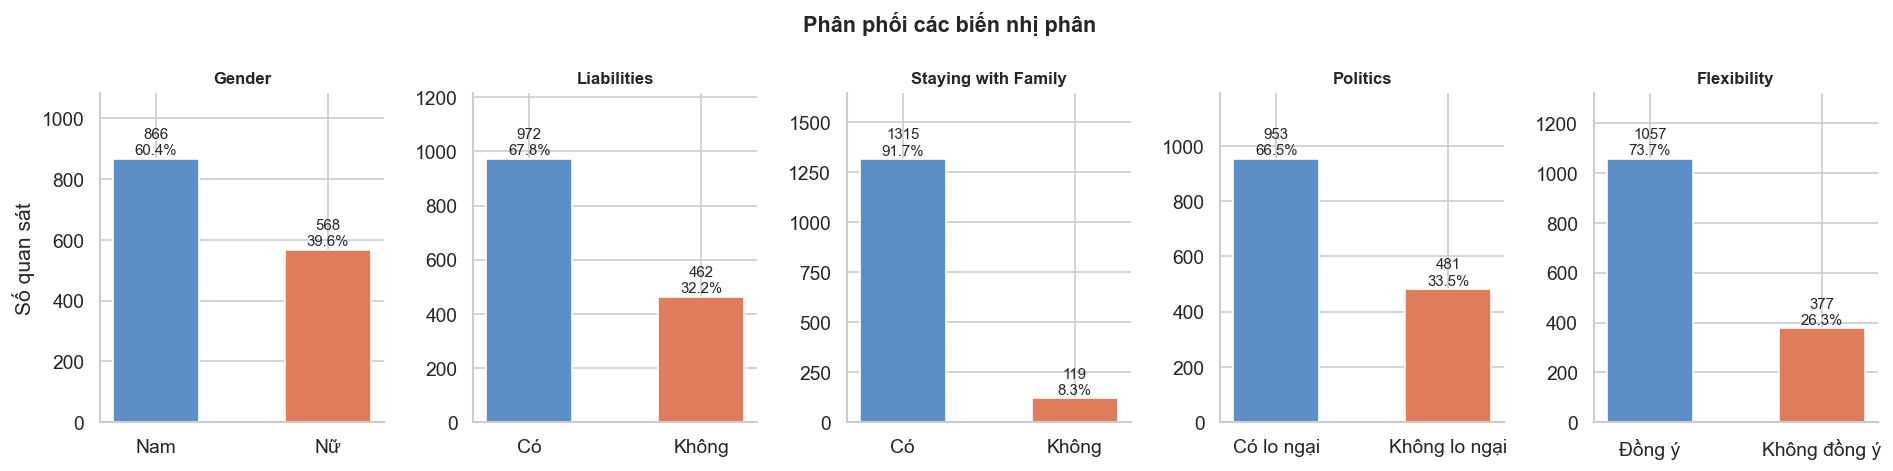

In [27]:
fig, axes = plt.subplots(1, len(BINARY_COLS), figsize=(16, 4))

for ax, col in zip(axes, BINARY_COLS):
    counts_col = df_raw[col].value_counts().sort_index()
    tick_labels = [LABEL_MAP.get(col, {}).get(k, str(k)) for k in counts_col.index]
    bars = ax.bar(tick_labels, counts_col.values,
                  color=['#5C8EC7', '#E07B5C'], width=0.5, edgecolor='white')
    for bar, n in zip(bars, counts_col.values):
        pct_val = n / counts_col.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{n}\n{pct_val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(col.replace('_', ' '), fontweight='bold', fontsize=10)
    ax.set_ylim(0, counts_col.max() * 1.25)
    ax.set_ylabel('Số quan sát' if col == BINARY_COLS[0] else '')

plt.suptitle('Phân phối các biến nhị phân', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_binary_distribution.png', bbox_inches='tight')
plt.show()

### Task 5: Phân phối các biến thứ bậc (Ordinal)

- Khảo sát **Age, BMI, Income, số thành viên gia đình, thâm niên công tác, giờ làm và ngày nghỉ hàng tuần**.

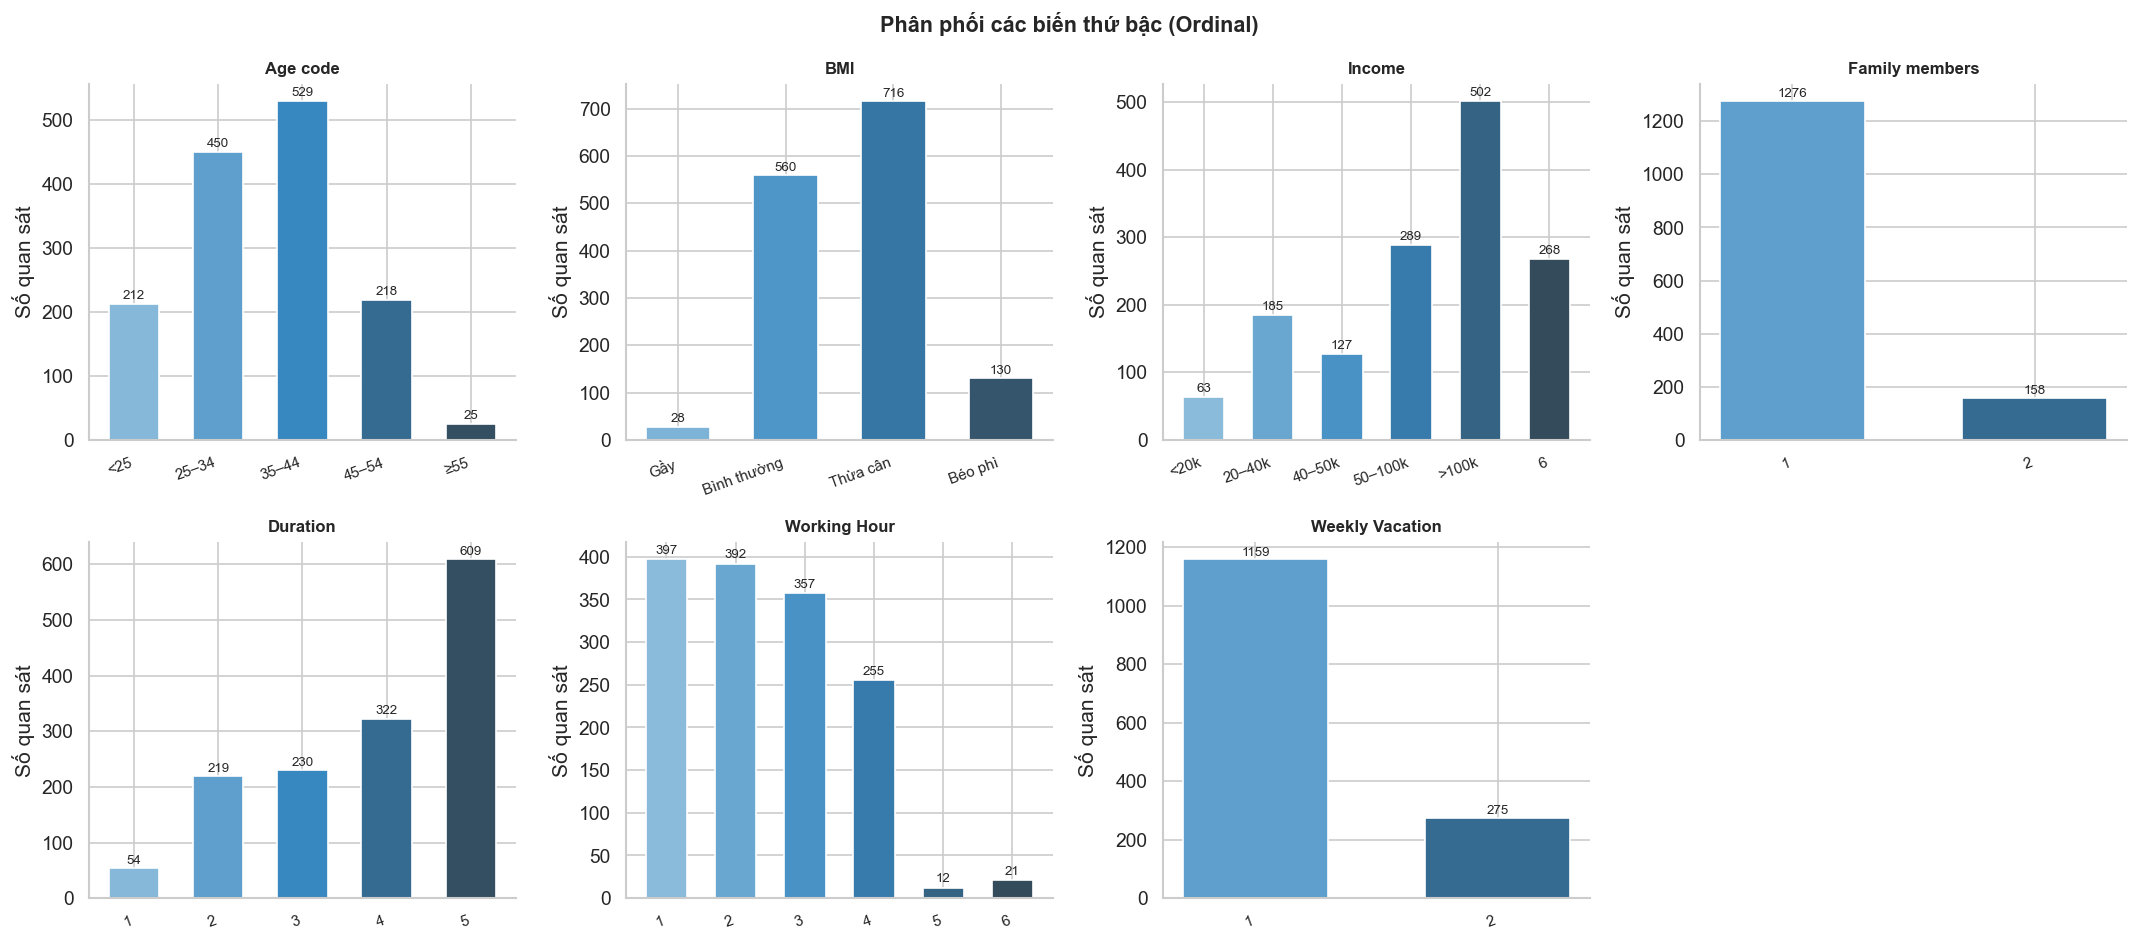

In [28]:
n_cols = 4
n_rows = int(np.ceil(len(ORDINAL_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes_flat = axes.flatten()

for i, col in enumerate(ORDINAL_COLS):
    ax = axes_flat[i]
    counts_col = df_raw[col].value_counts().sort_index()
    tick_labels = [LABEL_MAP.get(col, {}).get(k, str(k)) for k in counts_col.index]
    palette = sns.color_palette('Blues_d', len(counts_col))
    bars = ax.bar(range(len(counts_col)), counts_col.values,
                  color=palette, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(counts_col)))
    ax.set_xticklabels(tick_labels, rotation=20, ha='right', fontsize=9)
    for bar, n in zip(bars, counts_col.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(n), ha='center', va='bottom', fontsize=8)
    ax.set_title(col.replace('_', ' '), fontweight='bold', fontsize=10)
    ax.set_ylabel('Số quan sát')

for j in range(len(ORDINAL_COLS), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Phân phối các biến thứ bậc (Ordinal)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_ordinal_distribution.png', bbox_inches='tight')
plt.show()

### Task 6: Phân phối các biến danh nghĩa (Nominal)

- Vẽ biểu đồ ngang (horizontal bar) để dễ đọc nhãn danh mục dài.

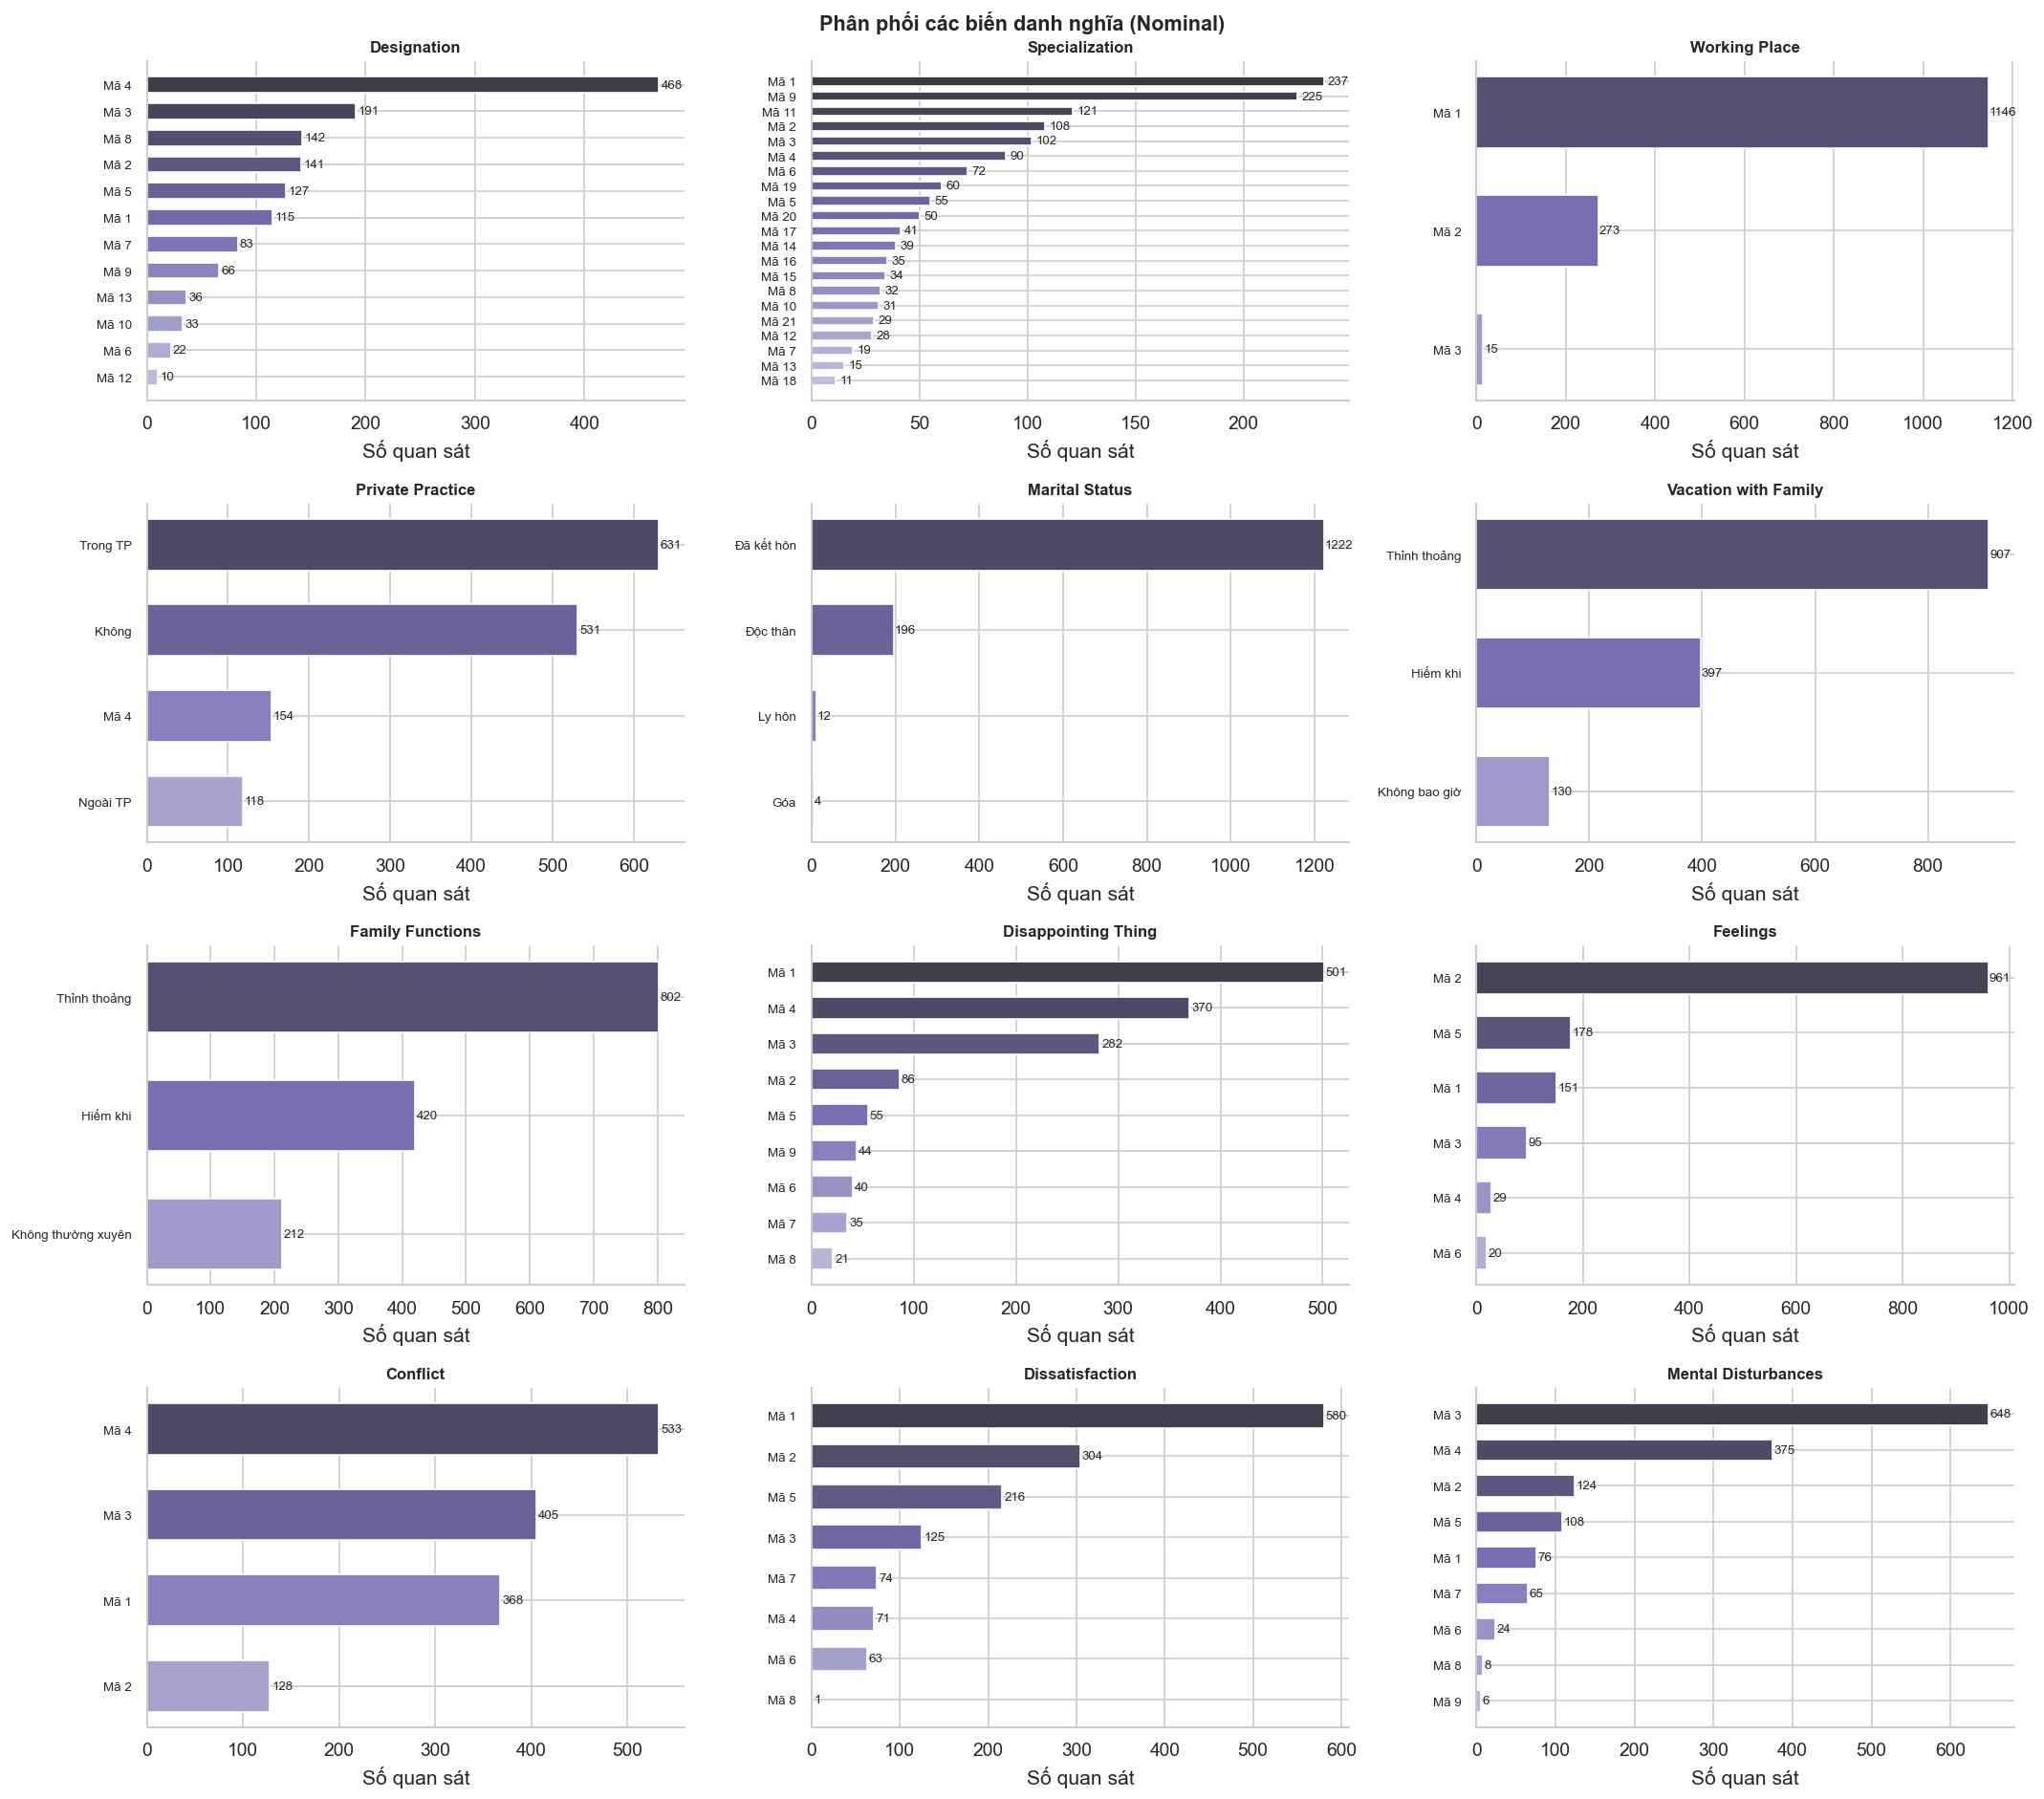

In [29]:
n_cols = 3
n_rows = int(np.ceil(len(NOMINAL_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes_flat = axes.flatten()

for i, col in enumerate(NOMINAL_COLS):
    ax = axes_flat[i]
    counts_col = df_raw[col].value_counts().sort_values(ascending=True)
    tick_labels = [LABEL_MAP.get(col, {}).get(k, f'Mã {k}') for k in counts_col.index]
    palette = sns.color_palette('Purples_d', len(counts_col))
    bars = ax.barh(range(len(counts_col)), counts_col.values,
                   color=palette, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(counts_col)))
    ax.set_yticklabels(tick_labels, fontsize=8)
    for bar, n in zip(bars, counts_col.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                str(n), va='center', fontsize=8)
    ax.set_title(col.replace('_', ' '), fontweight='bold', fontsize=10)
    ax.set_xlabel('Số quan sát')

for j in range(len(NOMINAL_COLS), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Phân phối các biến danh nghĩa (Nominal)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_nominal_distribution.png', bbox_inches='tight')
plt.show()

### Task 7: Correlation Heatmap (tất cả biến vs Burn Out)

- Tính **Spearman correlation** (phù hợp cho dữ liệu thứ bậc và mã hóa số) giữa tất cả features và biến mục tiêu, sau đó hiển thị full heatmap và bảng xếp hạng.

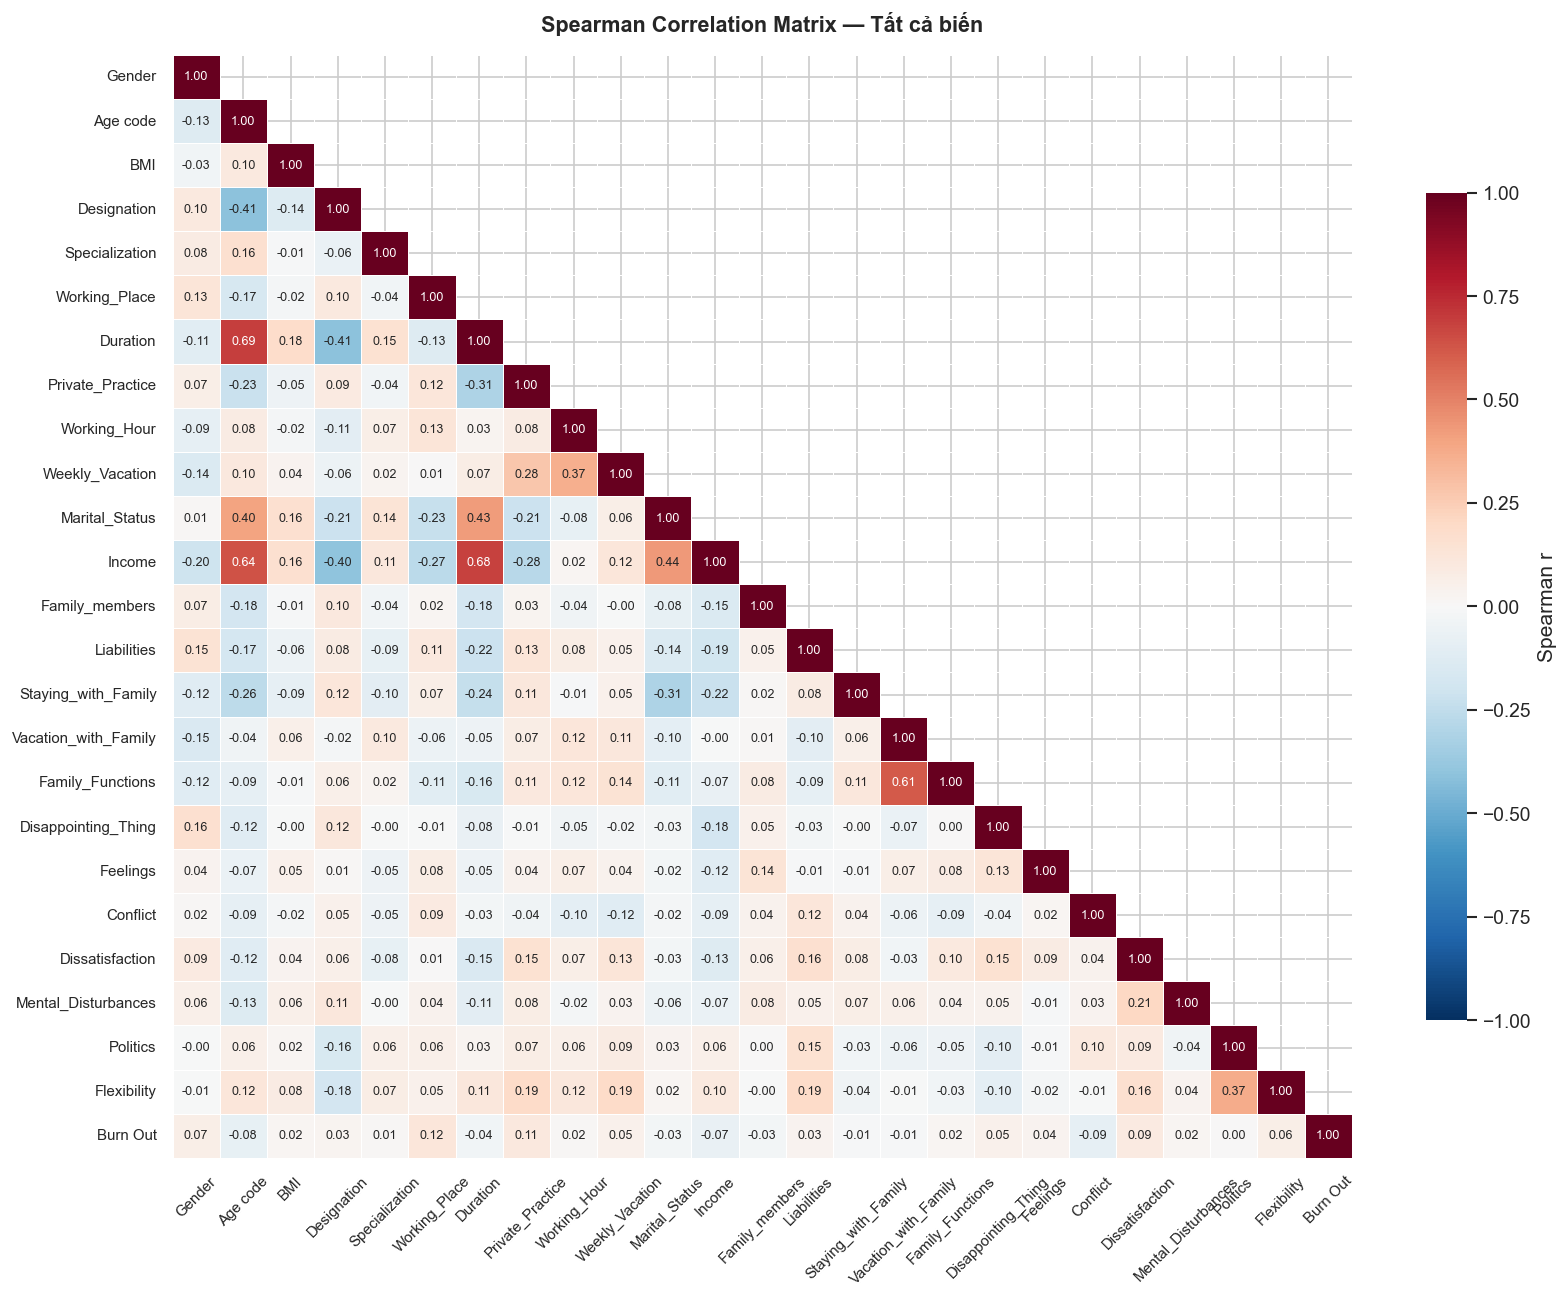

In [ ]:
# ── Tính Spearman correlation matrix ──────────────────────────────────────
corr_matrix = df_raw.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # Chỉ giữ tam giác dưới
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Spearman r'},
    ax=ax
)
ax.set_title('Spearman Correlation Matrix — Tất cả biến', fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

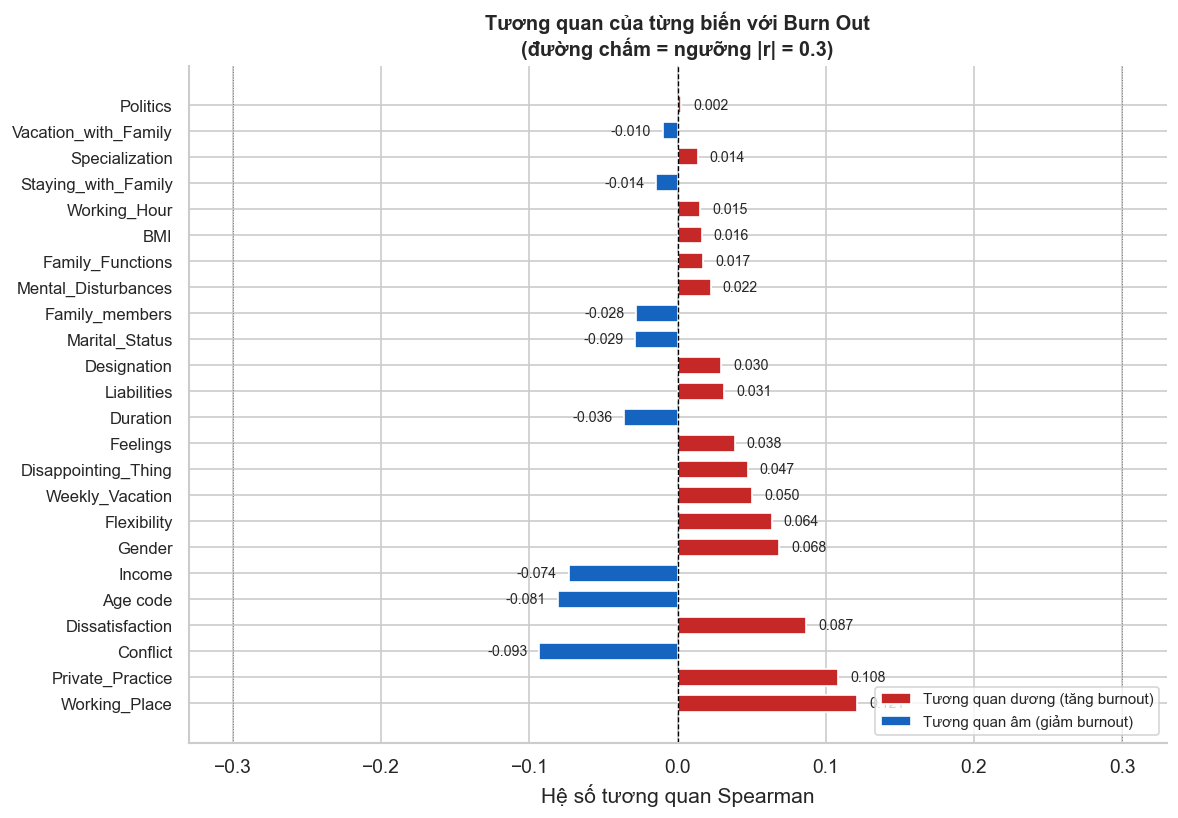


📊 Top 10 biến tương quan mạnh nhất với Burn Out:


,Biến,Spearman r
0,Working_Place,0.121356
1,Private_Practice,0.108440
2,Conflict,-0.093394
3,Dissatisfaction,0.086672
4,Age code,-0.080855
5,Income,-0.073612
6,Gender,0.068476
7,Flexibility,0.063510
8,Weekly_Vacation,0.050481
9,Disappointing_Thing,0.047341


In [31]:
# Xếp hạng tương quan với Burn Out
corr_with_target = (
    corr_matrix[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#C62828' if v > 0 else '#1565C0' for v in corr_with_target.values]
bars = ax.barh(range(len(corr_with_target)), corr_with_target.values,
               color=colors_bar, edgecolor='white', height=0.65)
ax.set_yticks(range(len(corr_with_target)))
ax.set_yticklabels(corr_with_target.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline( 0.3, color='grey', linewidth=0.6, linestyle=':')
ax.axvline(-0.3, color='grey', linewidth=0.6, linestyle=':')
for bar, val in zip(bars, corr_with_target.values):
    offset = 0.008 if val >= 0 else -0.008
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8.5)
ax.set_xlabel('Hệ số tương quan Spearman')
ax.set_title('Tương quan của từng biến với Burn Out\n(đường chấm = ngưỡng |r| = 0.3)',
             fontweight='bold', fontsize=12)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C62828', label='Tương quan dương (tăng burnout)'),
                   Patch(facecolor='#1565C0', label='Tương quan âm (giảm burnout)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/06_correlation_with_burnout.png', bbox_inches='tight')
plt.show()

print("\n📊 Top 10 biến tương quan mạnh nhất với Burn Out:")
display(corr_with_target.head(10).reset_index()
        .rename(columns={'index': 'Biến', TARGET_COL: 'Spearman r'}))

### Task 8: Phân tích theo giới tính (Gender vs Burn Out)

- So sánh phân phối mức độ burnout giữa nam và nữ bằng stacked bar chart và boxplot.

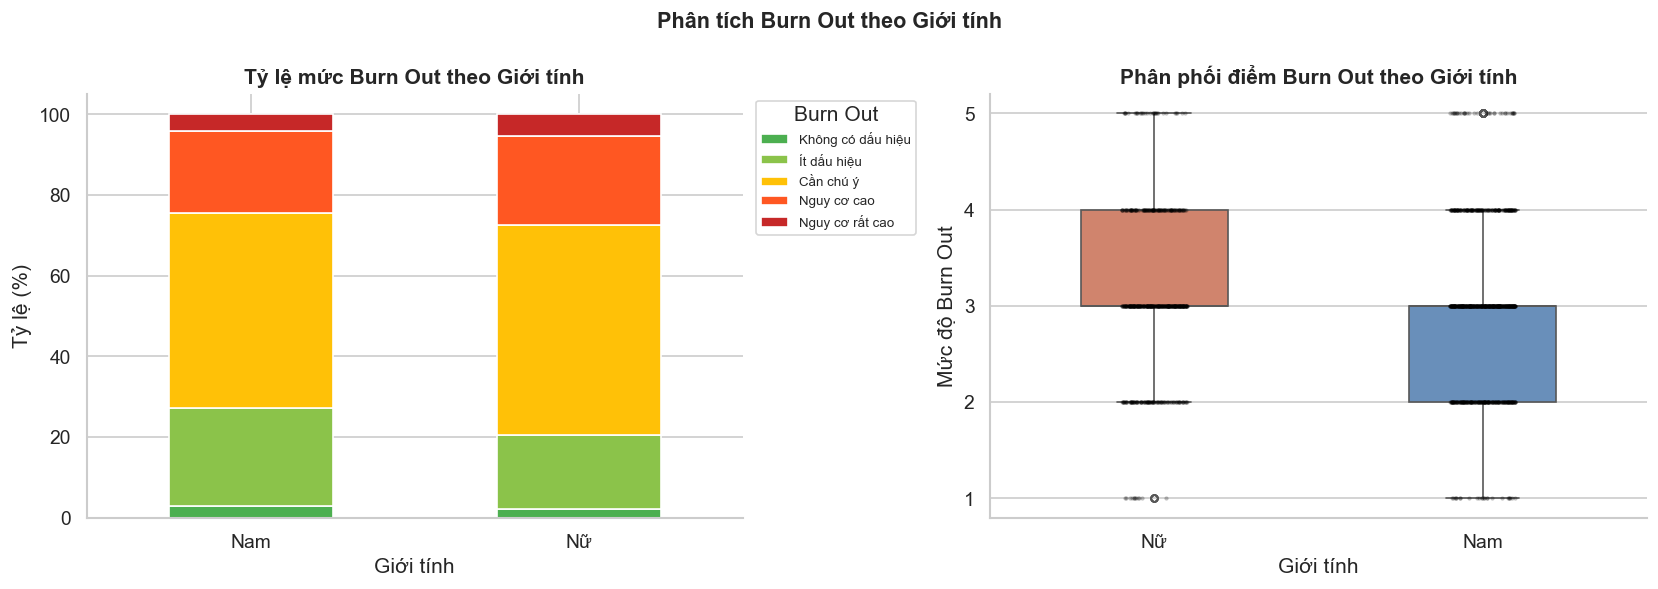


📊 Thống kê mô tả Burn Out theo Giới tính:


,count,mean,std,min,25%,50%,75%,max
Gender_label,,,,,,,,
Nam,866.0,2.99,0.85,1.0,2.0,3.0,3.0,5.0
Nữ,568.0,3.10,0.83,1.0,3.0,3.0,4.0,5.0


In [ ]:
df_plot = df_raw.copy()
df_plot['Gender_label']   = df_plot['Gender'].map(LABEL_MAP['Gender'])
df_plot['BurnOut_label']  = df_plot[TARGET_COL].map(LABEL_MAP[TARGET_COL])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart (tỷ lệ %)
ct = pd.crosstab(df_plot['Gender_label'], df_plot[TARGET_COL], normalize='index') * 100
ct.columns = [LABEL_MAP[TARGET_COL][c] for c in ct.columns]
ct.plot(kind='bar', stacked=True, ax=axes[0],
        color=[BURNOUT_PALETTE[k] for k in sorted(BURNOUT_PALETTE)],
        edgecolor='white', width=0.5)
axes[0].set_title('Tỷ lệ mức Burn Out theo Giới tính', fontweight='bold')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Burn Out', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Boxplot phân phối điểm Burn Out 
sns.boxplot(data=df_plot, x='Gender_label', y=TARGET_COL, ax=axes[1],
            palette={'Nam': '#5C8EC7', 'Nữ': '#E07B5C'},
            width=0.45, flierprops=dict(marker='o', markersize=4, alpha=0.5))
sns.stripplot(data=df_plot, x='Gender_label', y=TARGET_COL, ax=axes[1],
              color='black', size=2.5, alpha=0.25, jitter=True)
axes[1].set_title('Phân phối điểm Burn Out theo Giới tính', fontweight='bold')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Mức độ Burn Out')
axes[1].set_yticks([1, 2, 3, 4, 5])

plt.suptitle('Phân tích Burn Out theo Giới tính', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_burnout_by_gender.png', bbox_inches='tight')
plt.show()

print("\n📊 Thống kê mô tả Burn Out theo Giới tính:")
display(df_plot.groupby('Gender_label')[TARGET_COL]
        .describe().round(2))

### Task 9: Phân tích theo nhóm tuổi (Age vs Burn Out)

- Xem xu hướng burnout tăng hay giảm theo độ tuổi.

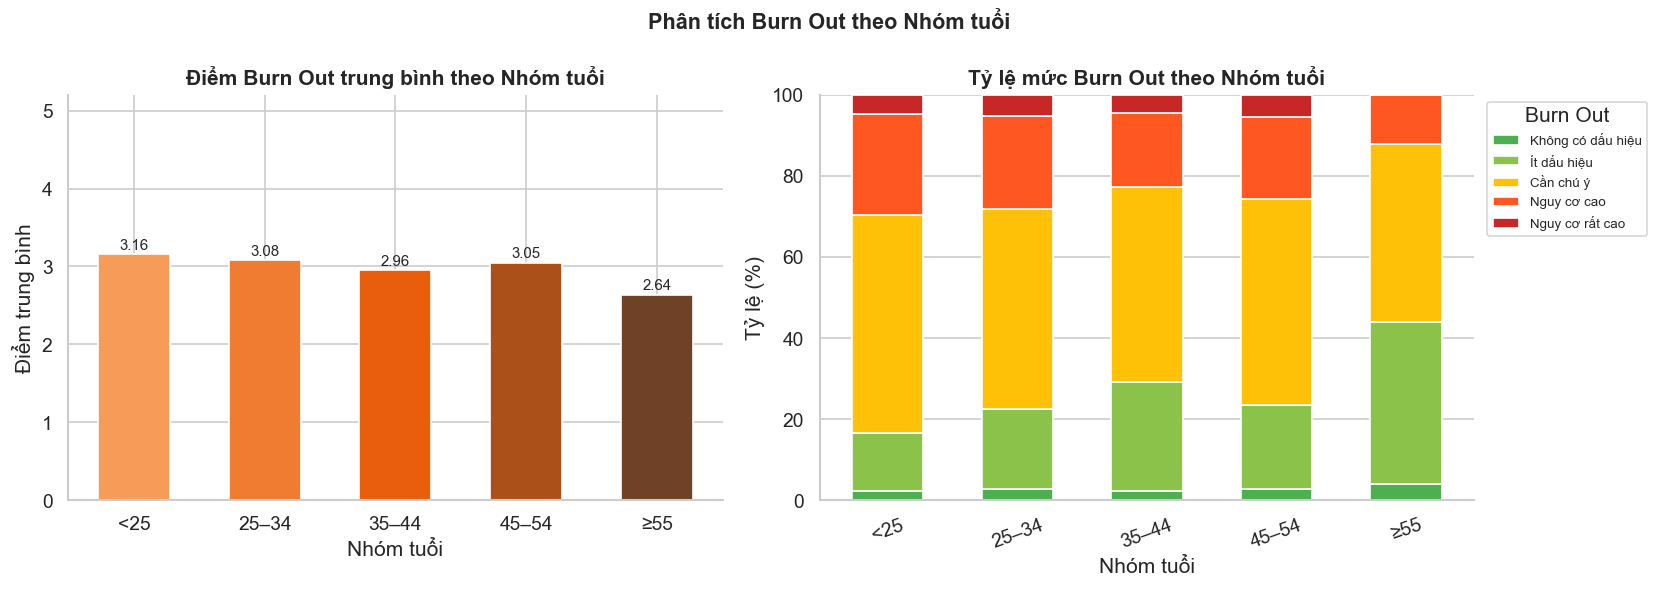

In [ ]:
df_plot['Age_label'] = df_plot['Age code'].map(LABEL_MAP['Age code'])
age_order = ['<25', '25–34', '35–44', '45–54', '≥55']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean Burn Out score theo nhóm tuổi
mean_by_age = (df_plot.groupby('Age_label', observed=True)[TARGET_COL]
               .mean().reindex(age_order))
bars = axes[0].bar(mean_by_age.index, mean_by_age.values,
                   color=sns.color_palette('Oranges_d', len(mean_by_age)),
                   width=0.55, edgecolor='white')
for bar, v in zip(bars, mean_by_age.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, 5.2)
axes[0].set_title('Điểm Burn Out trung bình theo Nhóm tuổi', fontweight='bold')
axes[0].set_xlabel('Nhóm tuổi')
axes[0].set_ylabel('Điểm trung bình')

# Stacked bar chart tỷ lệ
ct_age = (pd.crosstab(df_plot['Age_label'], df_plot[TARGET_COL], normalize='index') * 100)
ct_age = ct_age.reindex(age_order).fillna(0)
ct_age.columns = [LABEL_MAP[TARGET_COL][c] for c in ct_age.columns]
ct_age.plot(kind='bar', stacked=True, ax=axes[1],
            color=[BURNOUT_PALETTE[k] for k in sorted(BURNOUT_PALETTE)],
            edgecolor='white', width=0.55)
axes[1].set_title('Tỷ lệ mức Burn Out theo Nhóm tuổi', fontweight='bold')
axes[1].set_xlabel('Nhóm tuổi')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Burn Out', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Phân tích Burn Out theo Nhóm tuổi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/08_burnout_by_age.png', bbox_inches='tight')
plt.show()

### Task 10: Phân tích theo Designation (Chức danh vs Burn Out)

- Top 10 chức danh có điểm burnout trung bình cao nhất.

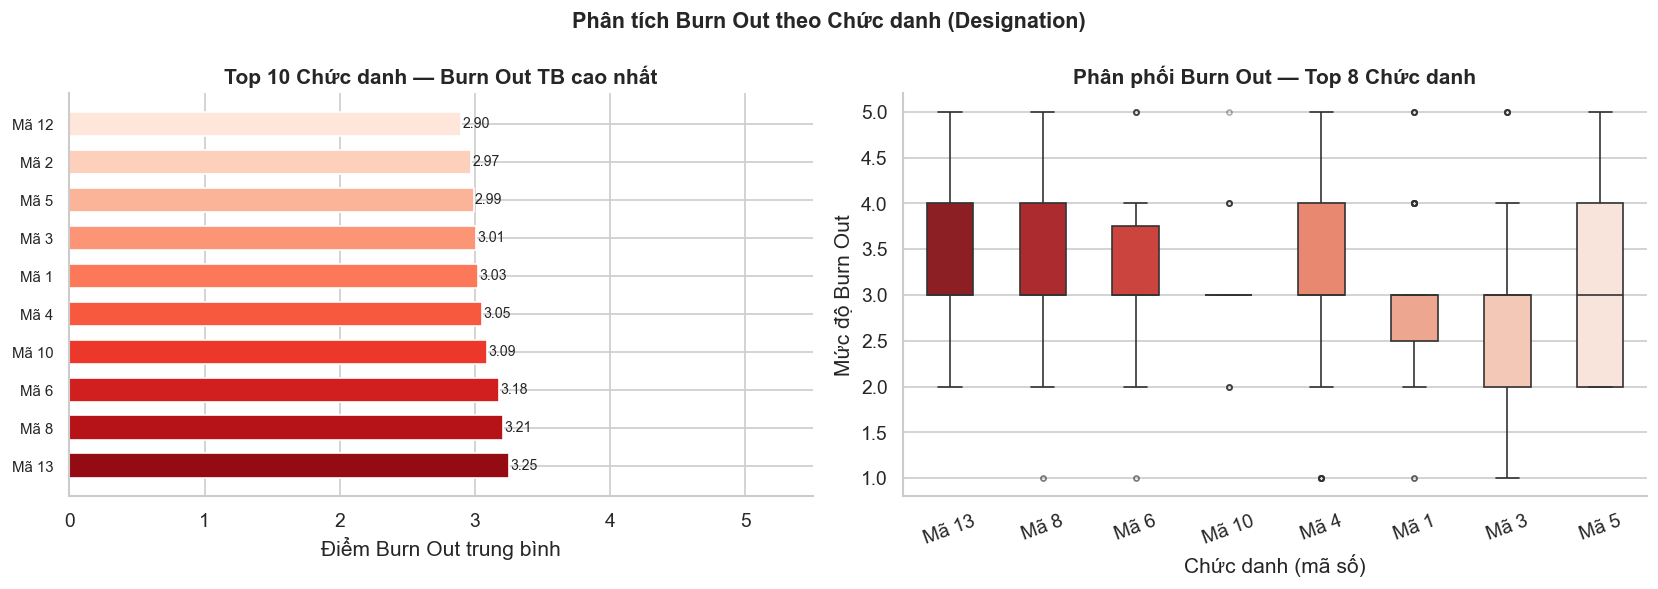


📊 Bảng thống kê đầy đủ:


,Designation,Điểm TB,Số quan sát
0,13,3.250000,36
1,8,3.211268,142
2,6,3.181818,22
3,10,3.090909,33
4,4,3.053419,468
5,1,3.026087,115
6,3,3.010471,191
7,5,2.992126,127
8,2,2.971631,141
9,12,2.900000,10


In [34]:
desig_stats = (df_raw.groupby('Designation')[TARGET_COL]
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'Điểm TB', 'count': 'Số quan sát'})
               .query('`Số quan sát` >= 10')      # chỉ lấy nhóm có đủ mẫu
               .sort_values('Điểm TB', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 Designation có burnout cao nhất
top10 = desig_stats.head(10)
palette_top = sns.color_palette('Reds_r', len(top10))
bars = axes[0].barh(range(len(top10)), top10['Điểm TB'].values,
                    color=palette_top, edgecolor='white', height=0.65)
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels([f'Mã {int(d)}' for d in top10.index], fontsize=9)
for bar, val in zip(bars, top10['Điểm TB'].values):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8.5)
axes[0].set_title('Top 10 Chức danh — Burn Out TB cao nhất', fontweight='bold')
axes[0].set_xlabel('Điểm Burn Out trung bình')
axes[0].set_xlim(0, 5.5)

# Boxplot theo Designation (top 8)
top8_desig = list(desig_stats.head(8).index)
df_top8 = df_raw[df_raw['Designation'].isin(top8_desig)].copy()
df_top8['Designation_str'] = df_top8['Designation'].apply(lambda x: f'Mã {int(x)}')
order_labels = [f'Mã {int(d)}' for d in desig_stats.head(8).index]
sns.boxplot(data=df_top8, x='Designation_str', y=TARGET_COL, ax=axes[1],
            order=order_labels,
            palette=sns.color_palette('Reds_r', 8),
            width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('Phân phối Burn Out — Top 8 Chức danh', fontweight='bold')
axes[1].set_xlabel('Chức danh (mã số)')
axes[1].set_ylabel('Mức độ Burn Out')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Phân tích Burn Out theo Chức danh (Designation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/09_burnout_by_designation.png', bbox_inches='tight')
plt.show()

print("\n📊 Bảng thống kê đầy đủ:")
display(desig_stats.reset_index())

### Task 11: Phân tích đa biến: Giới tính × Nhóm tuổi × Burn Out

- Dùng FacetGrid để thấy sự tương tác giữa 3 biến cùng lúc.

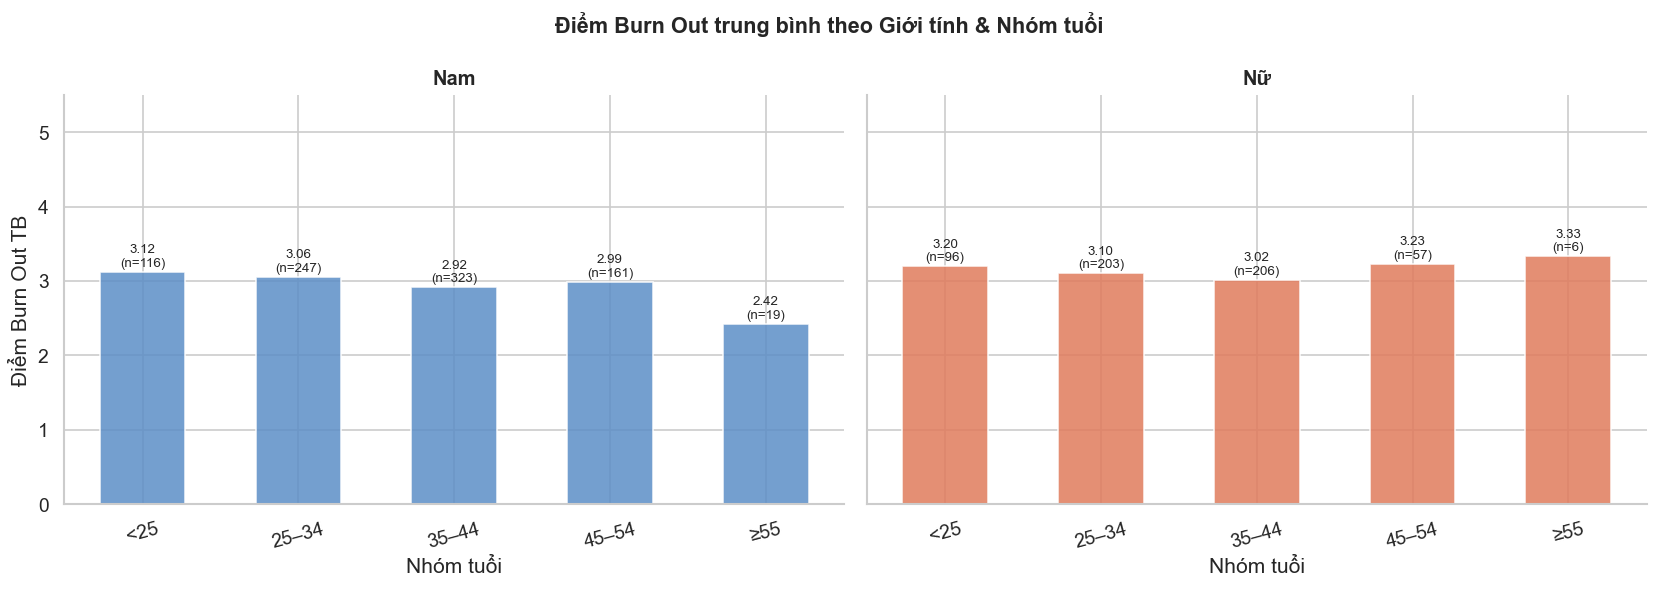

In [35]:
df_plot['Age_label'] = pd.Categorical(df_plot['Age_label'], categories=age_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (gender_code, gender_label) in zip(axes, [(1, 'Nam'), (2, 'Nữ')]):
    subset = df_plot[df_plot['Gender'] == gender_code]
    mean_pivot = (subset.groupby('Age_label', observed=True)[TARGET_COL]
                  .mean().reindex(age_order))
    count_pivot = (subset.groupby('Age_label', observed=True)[TARGET_COL]
                   .count().reindex(age_order))
    color = '#5C8EC7' if gender_label == 'Nam' else '#E07B5C'
    bars = ax.bar(mean_pivot.index, mean_pivot.values, color=color,
                  width=0.55, edgecolor='white', alpha=0.85)
    for bar, v, n in zip(bars, mean_pivot.values, count_pivot.values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                    f'{v:.2f}\n(n={int(n)})', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{gender_label}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel('Điểm Burn Out TB' if gender_label == 'Nam' else '')
    ax.set_ylim(0, 5.5)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Điểm Burn Out trung bình theo Giới tính & Nhóm tuổi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/10_burnout_gender_age.png', bbox_inches='tight')
plt.show()

### Task 12: Tổng kết nhận xét EDA

- Ghi lại các phát hiện chính để phục vụ báo cáo.

In [42]:
# ── Tự động tổng hợp các con số quan trọng ────────────────────────────────
n_total   = len(df_raw)
burnout_dist = df_raw[TARGET_COL].value_counts(normalize=True).sort_index() * 100
top3_corr    = corr_with_target.head(3)
dominant_grp = burnout_dist.idxmax()

print("=" * 60)
print("       TỔNG KẾT PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)")
print("=" * 60)

print(f"""
📌 DATASET
   • Tổng số quan sát   : {n_total:,} dòng
   • Số biến đặc trưng  : {df_raw.shape[1] - 1} features
   • Missing values     : Không có

📌 BIẾN MỤC TIÊU (Burn Out)
   • Nhóm 1 - Không có dấu hiệu : {burnout_dist.get(1, 0):.1f}%
   • Nhóm 2 -  Ít dấu hiệu       : {burnout_dist.get(2, 0):.1f}%
   • Nhóm 3 -  Cần chú ý (*)     : {burnout_dist.get(3, 0):.1f}%  <- Chiếm đa số
   • Nhóm 4 -  Nguy cơ cao       : {burnout_dist.get(4, 0):.1f}%
   • Nhóm 5 -  Nguy cơ rất cao   : {burnout_dist.get(5, 0):.1f}%
   ⚠️  Class imbalance: Nhóm {dominant_grp} chiếm {burnout_dist[dominant_grp]:.1f}%
      → Dùng class_weight='balanced' khi huấn luyện Random Forest.

📌 TOP 3 BIẾN TƯƠNG QUAN MẠNH NHẤT VỚI BURN OUT
   • {top3_corr.index[0]:25s}: r = {top3_corr.iloc[0]:.3f}
   • {top3_corr.index[1]:25s}: r = {top3_corr.iloc[1]:.3f}
   • {top3_corr.index[2]:25s}: r = {top3_corr.iloc[2]:.3f}

📌 NHÂN KHẨU HỌC
   • Phân tích Gender vs Burn Out: xem biểu đồ 07.
   • Phân tích Age vs Burn Out   : xem biểu đồ 08.
   • Phân tích Designation       : xem biểu đồ 09.
   • Tương tác Gender × Age      : xem biểu đồ 10.

📌 KHUYẾN NGHỊ CHO BƯỚC TIẾP THEO (02_preprocessing.ipynb)
   1. One-Hot Encoding các biến nominal.
   2. Giữ nguyên các biến ordinal (đã có thứ tự).
   3. Chuyển binary (1,2) → (0,1).
   4. Xét loại bỏ biến có |r| < 0.05 với Burn Out (nếu muốn giảm chiều).
   5. Áp dụng class_weight='balanced' trong Random Forest.
""")
print("=" * 60)
print("✅ EDA hoàn tất. Tất cả biểu đồ đã lưu vào reports/figures/")

       TỔNG KẾT PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

📌 DATASET
   • Tổng số quan sát   : 1,434 dòng
   • Số biến đặc trưng  : 24 features
   • Missing values     : Không có

📌 BIẾN MỤC TIÊU (Burn Out)
   • Nhóm 1 - Không có dấu hiệu : 2.5%
   • Nhóm 2 -  Ít dấu hiệu       : 22.0%
   • Nhóm 3 -  Cần chú ý (*)     : 49.8%  <- Chiếm đa số
   • Nhóm 4 -  Nguy cơ cao       : 20.9%
   • Nhóm 5 -  Nguy cơ rất cao   : 4.7%
   ⚠️  Class imbalance: Nhóm 3 chiếm 49.8%
      → Dùng class_weight='balanced' khi huấn luyện Random Forest.

📌 TOP 3 BIẾN TƯƠNG QUAN MẠNH NHẤT VỚI BURN OUT
   • Working_Place            : r = 0.121
   • Private_Practice         : r = 0.108
   • Conflict                 : r = -0.093

📌 NHÂN KHẨU HỌC
   • Phân tích Gender vs Burn Out: xem biểu đồ 07.
   • Phân tích Age vs Burn Out   : xem biểu đồ 08.
   • Phân tích Designation       : xem biểu đồ 09.
   • Tương tác Gender × Age      : xem biểu đồ 10.

📌 KHUYẾN NGHỊ CHO BƯỚC TIẾP THEO (02_preprocessing.ipynb)
   1. One-Hot Encod